In [17]:
from xgboost import XGBClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE, ADASYN


In [18]:
df = pd.read_csv("data/train-cat-encoded.csv")
print("Training set size: ", df.shape)
y = df['Will_Buy_EV']
x = df.drop(columns=['Will_Buy_EV'])


Training set size:  (668665, 22)


In [19]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
subsetNum = 50000
subset_x = x.iloc[:subsetNum]
subset_y = y.iloc[:subsetNum]
smote = SMOTE(random_state=42)
ada = ADASYN(n_neighbors=5, random_state=42)


==========XGBoost Cross Validation Training Loop==========

========== FOLD 1 ==========
Fold 1 | AUC: 0.8070
F1: 0.6817 | Recall: 0.6805 | Precision: 0.6828


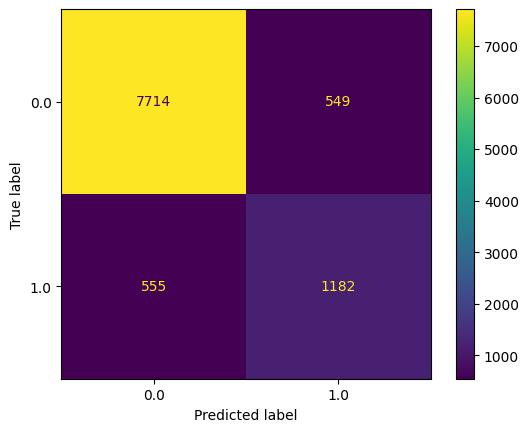

Finished Fold 1

========== FOLD 2 ==========
Fold 2 | AUC: 0.8149
F1: 0.7020 | Recall: 0.6864 | Precision: 0.7182


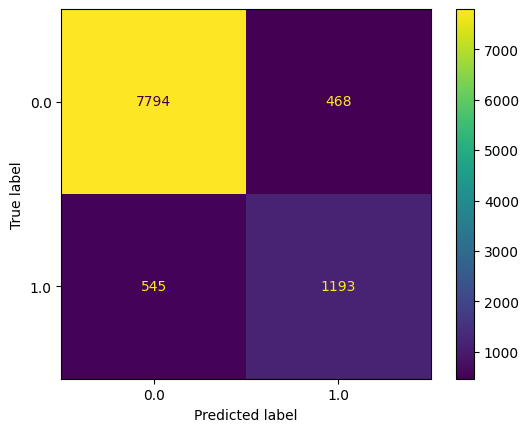

Finished Fold 2

========== FOLD 3 ==========
Fold 3 | AUC: 0.8163
F1: 0.7063 | Recall: 0.6870 | Precision: 0.7267


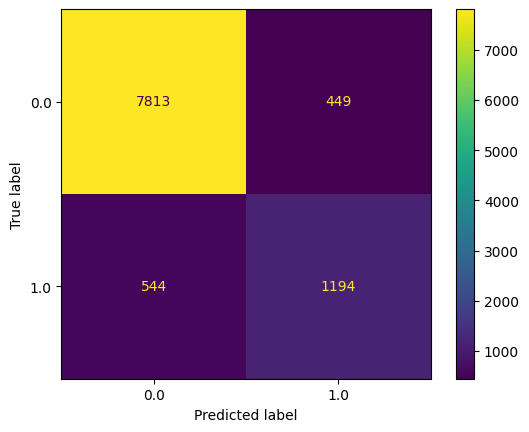

Finished Fold 3

========== FOLD 4 ==========
Fold 4 | AUC: 0.8100
F1: 0.6873 | Recall: 0.6847 | Precision: 0.6899


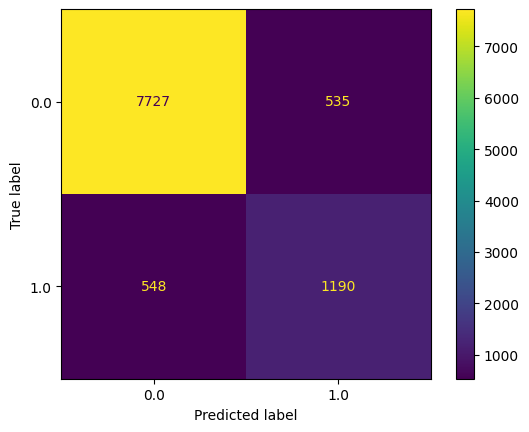

Finished Fold 4

========== FOLD 5 ==========
Fold 5 | AUC: 0.8033
F1: 0.6869 | Recall: 0.6628 | Precision: 0.7129


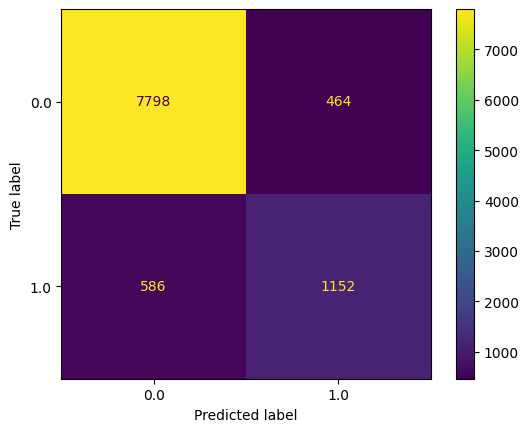

Finished Fold 5
Avg AUC: 0.8103
Avg F1: 0.6928
Avg Recall: 0.6803
Avg Precision: 0.7061
Std AUC: 0.004831724313563826


In [20]:
xgbAucList = []
xgbF1List = []
xgbRecallList = []
xgbPrecisionList = []

print("==========XGBoost Cross Validation Training Loop==========")
for fold, (train_idx, val_idx) in enumerate(skf.split(subset_x, subset_y)):
    print(f"\n========== FOLD {fold + 1} ==========")
    
    # 1. Split data (using .iloc if X/y are pandas DataFrames)
    X_train, X_val = subset_x.iloc[train_idx], subset_x.iloc[val_idx]
    y_train, y_val = subset_y.iloc[train_idx], subset_y.iloc[val_idx]
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
    # X_train_resampled, y_train_resampled = ada.fit_resample(X_train, y_train)

    model = XGBClassifier(
    n_estimators=100,      # number of boosting rounds (trees)
    max_depth=6,           # tree depth
    learning_rate=0.1,     # shrinkage per round
    subsample=0.8,         # row sampling per tree
    colsample_bytree=0.8,  # feature sampling per tree
    eval_metric='logloss'
)
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_val)
    auc = roc_auc_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)

    print(f"Fold {fold + 1} | AUC: {auc:.4f}")
    print(f"F1: {f1:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    ConfusionMatrixDisplay.from_predictions(y_val, y_pred)
    plt.show()
    xgbAucList.append(auc)
    xgbF1List.append(f1)
    xgbRecallList.append(recall)
    xgbPrecisionList.append(precision)
              
    print(f"Finished Fold {fold + 1}")

print(f"Avg AUC: {(sum(xgbAucList) / n_splits):.4f}")
print(f"Avg F1: {(sum(xgbF1List) / n_splits):.4f}")
print(f"Avg Recall: {(sum(xgbRecallList) / n_splits):.4f}")
print(f"Avg Precision: {(sum(xgbPrecisionList) / n_splits):.4f}")
print(f"Std AUC: {np.std(xgbAucList)}")


### Without oversampling (10000 samples)
- Avg AUC: 0.7961
- Avg F1: 0.6768
- Avg Recall: 0.6476
- Avg Precision: 0.7091
- Std AUC: 0.011227993955145489

### With SMOTE 
- (10000 samples)
- Avg AUC: 0.8078
- Avg F1: 0.6816
- Avg Recall: 0.6823
- Avg Precision: 0.6811
- Std AUC: 0.010849068483999757

- (50000 samples)
- Avg AUC: 0.8103
- Avg F1: 0.6928
- Avg Recall: 0.6803
- Avg Precision: 0.7061
- Std AUC: 0.004831724313563826

### With ADASYN 
- (10000 samples)
- Avg AUC: 0.8061
- Avg F1: 0.6800
- Avg Recall: 0.6783
- Avg Precision: 0.6820
- Std AUC: 0.013100931517913382

- (50000 samples)
- Avg AUC: 0.8108
- Avg F1: 0.6930
- Avg Recall: 0.6819
- Avg Precision: 0.7048
- Std AUC: 0.003366363055176301